# VRPLIB

---

## *This is an exemple of how to import instances with VRPLIB*

### 1/ Import VRPLIB

In [1]:
import vrplib
import os
import matplotlib.pyplot as plt

### 2/ Import an instance 

In [2]:
instance_name = "M/M-n121-k7.vrp"
instance_path = os.path.join("..", "instances", instance_name)

data = vrplib.read_instance(instance_path, instance_format="vrplib")

#### Main informations

In [3]:
print("Available keys in this instance :")
print(list(data.keys()))

print(f"\nVehicules capacity : {data.get('capacity')}")
print(f"Depot indice : {data.get('depot', 0)}")

print("\nPremiers clients :")
for i in range(1, 6):
    print(f"Client {i} -> "
          f"Coord: {data['node_coord'][i]}, "
          f"Demand: {data['demand'][i]}, "
          f"edge_weight: {data['edge_weight'][i]}")
    

Available keys in this instance :
['name', 'comment', 'type', 'dimension', 'edge_weight_type', 'capacity', 'node_coord', 'demand', 'depot', 'edge_weight']

Vehicules capacity : 200
Depot indice : [0]

Premiers clients :
Client 1 -> Coord: [25  1], Demand: 25, edge_weight: [ 46.4865572    0.           2.           7.21110255   8.06225775
   8.48528137  10.63014581  12.04159458  22.47220505  11.66190379
  10.29563014  10.77032961  22.56102835  15.5241747   14.14213562
  11.18033989  48.25971405  48.50773134  35.0142828   51.2445119
  51.7880295   52.39274759  53.03772242  53.60037313  54.03702434
  54.14794548  54.91812087  57.03507693  57.31491952  66.49060084
  59.03388857  59.13543777  59.53990259  60.          62.12889827
  60.40695324  62.28964601  72.9451849   74.63243263  75.80237463
  80.72174428  76.55063684  78.23681998  81.83520025  78.54934755
  84.20213774  80.26207074  81.3019065   83.48652586  81.98780397
  86.60831369  88.75246475  98.00510191 100.43903624 100.
 103.22790

### 4/ Draw the nodes and the depot

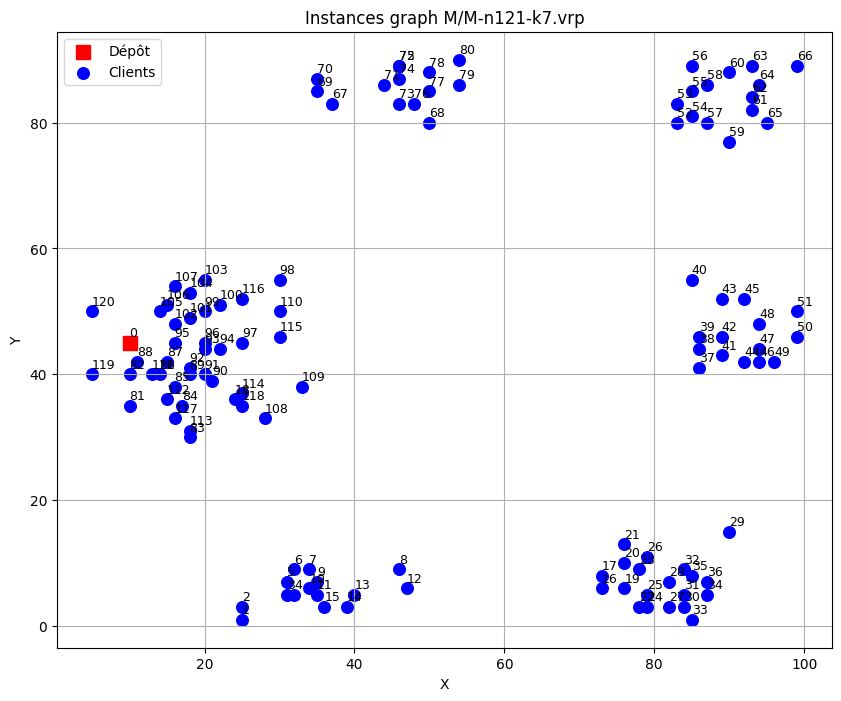

In [4]:
coords = data['node_coord']
x = [c[0] for c in coords]
y = [c[1] for c in coords]

plt.figure(figsize=(10, 8))

plt.scatter(x[0], y[0], c='red', s=100, label='Dépôt', marker='s')
plt.scatter(x[1:], y[1:], c='blue', s=70, label='Clients')

for i, (xi, yi) in enumerate(coords):
    plt.text(xi, yi+1, str(i), fontsize=9)

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Instances graph {instance_name}")
plt.legend()
plt.grid(True)
plt.show()


### 5/ The .sol solution

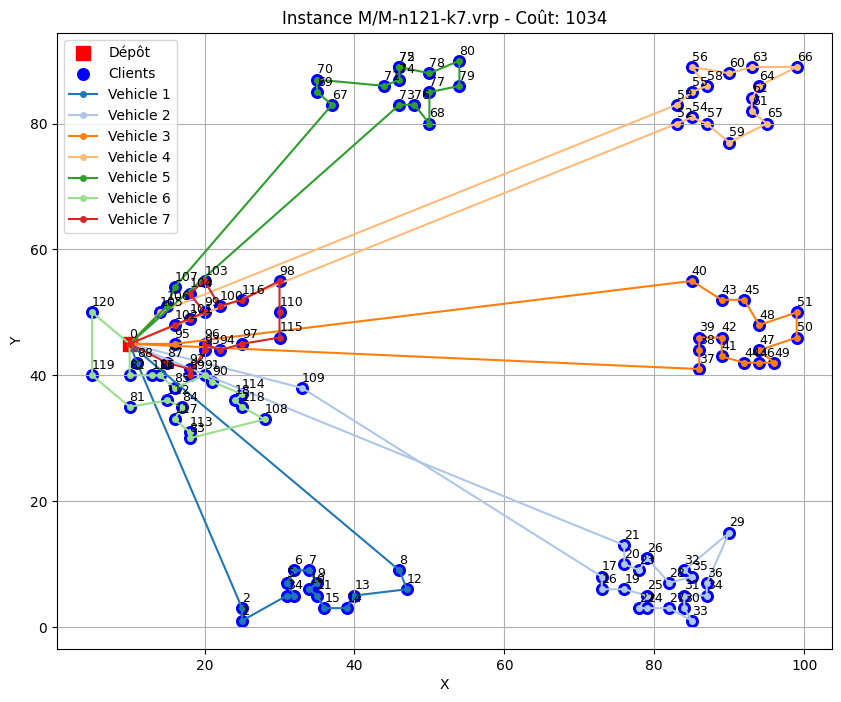

In [5]:
solution_path = os.path.join("..", "instances", instance_name.replace(".vrp", ".sol"))
solution = vrplib.read_solution(solution_path)


# Like before
coords = data['node_coord']
x = [c[0] for c in coords]
y = [c[1] for c in coords]

plt.figure(figsize=(10, 8))

plt.scatter(x[0], y[0], c='red', s=100, label='Dépôt', marker='s')
plt.scatter(x[1:], y[1:], c='blue', s=70, label='Clients')

for i, (xi, yi) in enumerate(coords):
    plt.text(xi, yi+1, str(i), fontsize=9)


# Drawing the trucks solutions
colors = plt.cm.tab20.colors

for i, route in enumerate(solution['routes']):
    full_route = [0] + route + [0]
    
    route_coords = [coords[node] for node in full_route]
    rx = [c[0] for c in route_coords]
    ry = [c[1] for c in route_coords]
    
    color = colors[i % len(colors)]
    plt.plot(rx, ry, '-o', color=color, label=f'Vehicle {i+1}', markersize=4, linewidth=1.5)

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Instance {instance_name} - Coût: {solution['cost']}")
plt.legend()
plt.grid(True)
plt.show()